# 01 — Model walkthrough on one synthetic user

A synthetic user is simulated with a **known** TDEE, tissue mass and water. We then run the filter as if
we only had what a real person has: morning scale readings (80% of days) and logged intake (90% of days,
±5% logging error). Because the truth is known, every estimate can be checked.

In [1]:
import sys
sys.path.insert(0, "../src")
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tdee import DEFAULT, Params, run, summarize, ols_tdee, SimConfig, simulate_user
from tdee.plotting import set_style, SERIES, INK_2
set_style()

In [2]:
rng = np.random.default_rng(7)
inputs, truth = simulate_user(SimConfig(days=84), rng)
prior = truth["T"].iloc[0] + 300          # a formula-based guess, off by 300 kcal
hist, _ = run(inputs, DEFAULT, prior_t=prior)
inputs.head()

,date,weight_kg,intake
0,2026-01-01,81.998378,2414.356453
1,2026-01-02,82.536974,3190.998961
2,2026-01-03,82.440102,2859.062162
3,2026-01-04,82.852699,3377.631849
4,2026-01-05,82.075417,2351.534457


## What the scale sees vs what is really there

The scale reads tissue + water + noise. The smoothed tissue estimate (RTS smoother) should follow the true
tissue mass, while the water state absorbs the day-to-day swings.

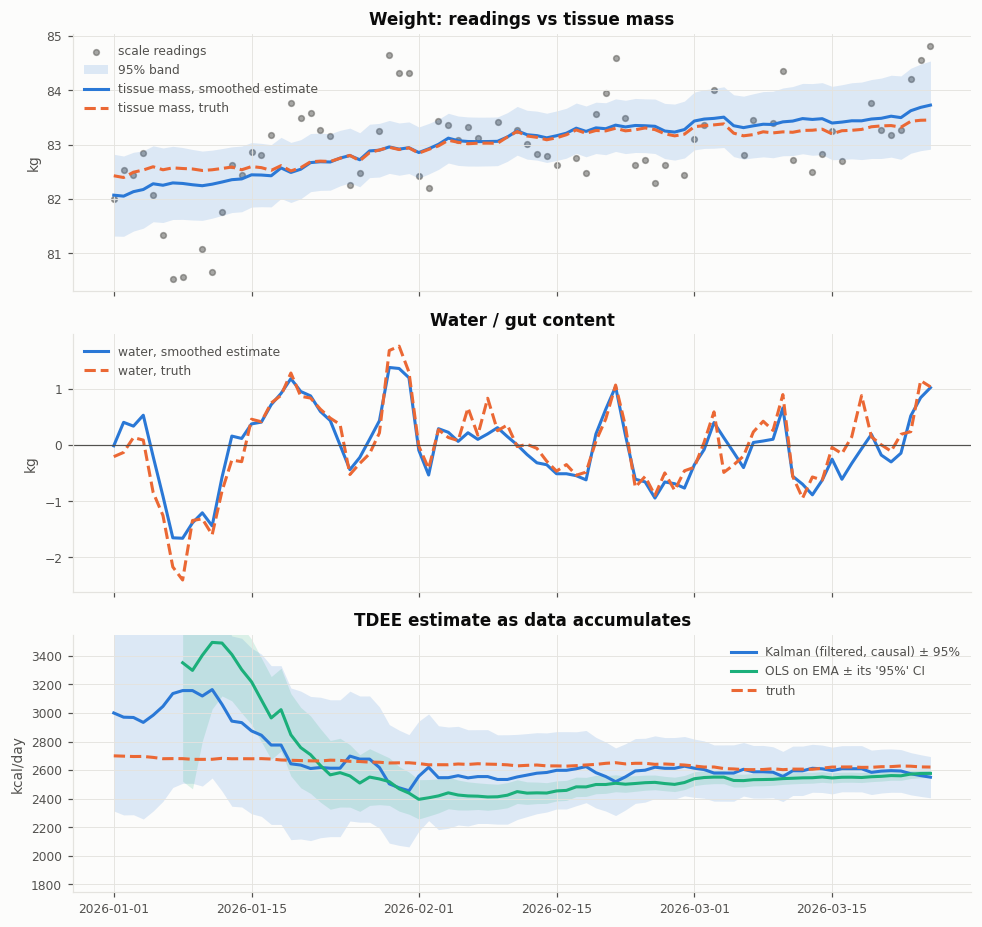

In [3]:
d = pd.to_datetime(hist["date"])
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)

ax = axes[0]
ax.scatter(d, inputs["weight_kg"], s=14, color=INK_2, alpha=0.5, label="scale readings")
ax.fill_between(d, hist["W_s"] - 1.96 * hist["W_s_sd"], hist["W_s"] + 1.96 * hist["W_s_sd"],
                color=SERIES[0], alpha=0.15, lw=0, label="95% band")
ax.plot(d, hist["W_s"], color=SERIES[0], label="tissue mass, smoothed estimate")
ax.plot(d, truth["W"], color=SERIES[1], ls="--", label="tissue mass, truth")
ax.set_ylabel("kg"); ax.set_title("Weight: readings vs tissue mass"); ax.legend(loc="upper left")

ax = axes[1]
ax.plot(d, hist["H_s"], color=SERIES[0], label="water, smoothed estimate")
ax.plot(d, truth["H"], color=SERIES[1], ls="--", label="water, truth")
ax.axhline(0, color=INK_2, lw=0.8)
ax.set_ylabel("kg"); ax.set_title("Water / gut content"); ax.legend(loc="upper left")

ema_est = []
for i in range(7, len(inputs)):
    w = inputs.iloc[: i + 1].dropna(subset=["weight_kg"])
    r = ols_tdee(w["date"], w["weight_kg"], inputs["intake"].iloc[:i].mean(), ema_halflife_days=5)
    ema_est.append((d.iloc[i], r["tdee"], r["tdee_ci95"]))
e = pd.DataFrame(ema_est, columns=["date", "tdee", "ci"])

ax = axes[2]
ax.fill_between(d, hist["T"] - 1.96 * hist["T_sd"], hist["T"] + 1.96 * hist["T_sd"],
                color=SERIES[0], alpha=0.15, lw=0)
ax.plot(d, hist["T"], color=SERIES[0], label="Kalman (filtered, causal) ± 95%")
ax.fill_between(e["date"], e["tdee"] - e["ci"], e["tdee"] + e["ci"], color=SERIES[2], alpha=0.15, lw=0)
ax.plot(e["date"], e["tdee"], color=SERIES[2], label="OLS on EMA ± its '95%' CI")
ax.plot(d, truth["T"], color=SERIES[1], ls="--", label="truth")
ax.set_ylim(truth["T"].mean() - 900, truth["T"].mean() + 900)
ax.set_ylabel("kcal/day"); ax.set_title("TDEE estimate as data accumulates"); ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("../figures/walkthrough.png", dpi=130)

In [4]:
s = summarize(hist)
print(f"true TDEE today      : {truth['T'].iloc[-1]:.0f}")
print(f"Kalman               : {s['tdee']:.0f} ± {s['tdee_ci95']:.0f}")
print(f"OLS on EMA           : {e['tdee'].iloc[-1]:.0f} ± {e['ci'].iloc[-1]:.0f}")

true TDEE today      : 2622
Kalman               : 2551 ± 144
OLS on EMA           : 2577 ± 29


## How a single reading moves the TDEE

TDEE is never observed. It moves because the filter carries a **negative covariance between tissue mass and
TDEE**: if expenditure were higher, less energy would have been stored and the scale would read lower. A
reading below expectation is therefore evidence for a higher TDEE, and the Kalman gain turns that covariance
into an update. A large share of each surprise is attributed to water, so a single reading moves TDEE by only
tens of kcal, and weeks of data are needed.

In [5]:
dT = hist["T"].diff().abs()[hist["y"].notna()].dropna()
print(f"median |TDEE update| on a day with a reading: {dT.median():.0f} kcal")
print(f"TDEE 95% half-width: day 7 = {1.96*hist['T_sd'].iloc[7]:.0f}, day 28 = {1.96*hist['T_sd'].iloc[28]:.0f}, "
      f"day 83 = {1.96*hist['T_sd'].iloc[83]:.0f} kcal")

median |TDEE update| on a day with a reading: 21 kcal
TDEE 95% half-width: day 7 = 649, day 28 = 415, day 83 = 144 kcal
